In [1]:
import re 
import seaborn as sns
from adjustText import adjust_text
import seaborn as sns 
import pandas as pd 
from utils.score import get_summary  
from utils.df import * 

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="serif"
) 
    
def extract_size(text):
    if pd.isna(text): return 1.0 # Default fallback
    match = re.search(r'\((\d+(?:\.\d+)?)[Bb]\)', text)
    return float(match.group(1)) if match else 1.0
    
model_results = {} 
vqa_1k = get_summary('vqa_1k').drop_duplicates(subset=['condition', 'question_id', 'model'])
vqa_5k = get_summary('vqa_5k').drop_duplicates(subset=['condition', 'question_id', 'model']) 
vqa_5k.condition.unique() 

pretrained_vlms = model_name_map.values()

85
89


In [34]:
import sys 
sys.path.append('..')
from score_humans import get_vqa_mapper, VQAAnswerMapper 

vqa_answers = get_vqa_mapper()  
vqamapper = VQAAnswerMapper()
vqamapper._load()
vqa_annot = vqamapper.annotations 

human_vqa = pd.read_json('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json')
human_vqa['model'] = "Humans" 
human_vqa['meta_model'] = "humans"
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric((human_vqa['correct'] * 100).round(1) , errors='coerce')
human_vqa['answer_similarity'] = pd.to_numeric((human_vqa['answer_similarity'] * 100).round(1) , errors='coerce')
human_vqa['question_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['question_type'] if int(qid) in vqa_annot else None)
human_vqa['answer_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['answer_type'] if int(qid) in vqa_annot else None)
human_vqa = human_vqa.drop_duplicates(subset=[ 'participant_id', 'question_id'])
human_vqa = human_vqa[human_vqa['participant_id'] != '13f54aa2_20251204_125847']
human_vqa.groupby('participant_id')['question_id'].nunique()  

   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


participant_id
02f952bb_20251210_230336            374
0756a860_20251124_133827            374
14d2420f_20251208_150302            374
218b2db5_20251126_084136            374
29127478_20251202_100107            374
2e184452_20251205_141511_cleaned    374
3238ebaf_20251126_140604            374
3a36e078_20251205_225238            374
5d843d39_20251127_141921            374
60de6bd6_20251210_170035            374
6b3a1a8d_20251125_135446            374
73df43f3_20251204_210431            374
74d408e5_20251213_134035            374
825ff3e9_20251210_192335            374
9c5d09f3_20251209_121033            374
a5909497_20251211_232822            374
b9b2cb98_20251127_193952            374
d1548553_20251125_202324            370
dd0f9986_20251128_222537            374
f616d5c7_20251203_212223            374
Name: question_id, dtype: int64

In [88]:
qids = human_vqa.question_id.unique()
model_vqa = vqa_1k[(vqa_1k['question_id'].isin(qids)) & (vqa_1k['condition'] == 'inst blind')].replace(model_name_map)
print(vqa_1k.condition.unique(),'condition mapped to-> ', model_vqa.condition.unique())

### combine human and model 
hm = pd.concat([model_vqa, human_vqa]) 
hm['model'] = hm['model']  # pt.to_csv(f'./tables/vqa_human_comparison.csv')      

### filtered datafrmes 
df = hm[['meta_model', 'question_id', 'answer_type', 'question_type', 'model', 'question', 'answer', 'output', 'correct', 'answer_similarity']]
human_df = df[df['model'] == 'Humans'] # .dropna(axis=1)   
humanavg= human_df.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index() 
model_df = df[df['model'] != 'Humans'] 

['' 'blind' 'inst blind'] condition mapped to->  ['inst blind']


In [36]:
mhavg = pd.merge( model_df, humanavg, on=['question_id', 'answer_type', 'question_type'], how='left', suffixes=('_model', '_human') )# .dropna(axis=1)
mhavg.groupby(['model']).count().head() # , len(qids), # model_vqa.groupby(['model', 'question_id']).count()   

,meta_model,question_id,answer_type,question_type,question,answer,output,correct_model,answer_similarity_model,correct_human,answer_similarity_human
model,,,,,,,,,,,
InternVL 3.5 (1B),374,374,374,374,374,0,374,374,374,0,0
InternVL 3.5 (2B),374,374,374,374,374,0,374,374,374,0,0
InternVL 3.5 (4B),374,374,374,374,374,0,374,374,374,0,0
InternVL 3.5 (8B),374,374,374,374,374,0,374,374,374,0,0
InternVL3_5-8B_A1_vqa_gt,374,374,374,374,374,0,374,374,374,0,0


In [157]:
from utils.corr import interrater_agreement 

def get_agreements(human_vqa, model_vqa, metrics="correct"): 
    human_acc = human_vqa.pivot(
        index="question_id",
        columns="participant_id",
        values=metrics
    )

    score_type = 'Accuracy' if metrics =='correct' else "Embedding Similarity"

    res_HH = interrater_agreement(
        human_acc,
        grp1=human_acc.columns,
        grp2=human_acc.columns,
        metric="spearman",
        title=f"Human–Human {score_type}",
    )

    model_acc = model_vqa.pivot(
        index="question_id",
        columns="model",
        values=metrics
    )

    res_MM = interrater_agreement(
        model_acc,
        grp1=model_acc.columns,
        grp2=model_acc.columns,
        metric="spearman",
        title=f"Model–Model {score_type}",
    )

    human_acc = human_vqa.pivot(
        index="question_id",
        columns="participant_id",
        values=metrics
    )

    model_acc = model_vqa.pivot(
        index="question_id",
        columns="model",
        values=metrics 
    )

    answers_pivot = human_acc.join(model_acc, how="inner")

    res_HM = interrater_agreement(
        answers_pivot,
        grp1=human_acc.columns,
        grp2=model_acc.columns,
        metric="spearman",
        title=f"Human–Model {score_type}",
    )
    return res_HH, res_MM, res_HM 

In [ ]:
res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa)  # accuarcy 
acc = pd.DataFrame([res_HH, res_MM, res_HM])

In [160]:
res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, 'answer_similarity')  
acc = pd.concat([acc, pd.DataFrame([res_HH, res_MM, res_HM ])]) 

100%|██████████| 200/200 [06:40<00:00,  2.00s/it]


In [171]:
def transform_corr_table(df): 
    df["comparison"] = df["title"].str.extract(
        r"(Human–Human|Human–Model|Model–Model)"
    )

    df["signal"] = df["title"].str.extract(
        r"(Accuracy|Embedding Similarity)"
    )

    # Clean signal naming
    df["signal"] = df["signal"].replace({
        "Embedding Similarity": "Embedding"
    })

    # 2. Create formatted mean [CI] column
    df["rho_ci"] = (
        df["mean_r"].round(3).astype(str)
        + " ["
        + df["ci_2p5"].round(3).astype(str)
        + ", "
        + df["ci_97p5"].round(3).astype(str)
        + "]"
    )
    # 3. Pivot table
    pivot = (
        df.pivot(
            index="comparison",
            columns="signal",
            values="rho_ci"
        )
        .reindex(
            ["Human–Human", "Human–Model", "Model–Model"]
        )
    )
    # 4. Rename columns for LaTeX
    pivot = pivot.rename(columns={
        "Accuracy": "Accuracy $\\rho$ ",
        "Embedding": "Embedding $\\rho$ "
    })
    return pivot 

transform_corr_table(acc).to_latex('./tables/3_spearman-interrater.tex', float_format="%.3f")   

In [197]:
df = calculate_mg(aggregate_vqa(vqa_5k), filename='vqa_5k') 
df = calculate_mg(aggregate_vqa(vqa_1k), filename='vqa_1k') 

In [258]:
hm.groupby(['model', 'answer_type']).size().unstack(fill_value=0).head()

answer_type,number,other,yes/no
model,,,
InternVL3_5-1B,35,158,181
InternVL3_5-2B,35,158,181
InternVL3_5-4B,35,158,181
InternVL3_5-8B,35,158,181
InternVL3_5-8B_A1_vqa_gt,35,158,181


In [ ]:
from utils.df import aggregate_vqa, model_name_map, calculate_mg 

agg = aggregate_vqa(hm).reset_index()
agg = agg[agg['model'].isin(list(pretrained_vlms))]
agg.columns = [col[1] if isinstance(col, tuple) and len(col) > 1 and col[1] else (col[0] if isinstance(col, tuple) else col) for col in agg.columns]
ag=agg.pivot_table( 
    index=['model'], 
    values=['answer_similarity_inst_blind', 'correct_inst_blind'], 
    columns=['answer_type'], 
    aggfunc=['mean']
)
# agg.to_latex('./tables/VQA_human-model_similarity-answer_type.tex', float_format="%.1f")  
ag.to_latex('./tables/1_VQA_human-pretrained-model_similarity-answer_type.tex', float_format="%.1f")   
ag

mean  ...                   
                        answer_similarity_inst_blind  ... correct_inst_blind
answer_type                                   number  ...             yes/no
model                                                 ...                   
Humans                                     54.293133  ...          66.564151
InternVL 3.5 (1B)                          67.474286  ...          68.322652
InternVL 3.5 (2B)                          61.708571  ...          74.585083
InternVL 3.5 (4B)                          62.408571  ...          74.400552
InternVL 3.5 (8B)                          66.285714  ...          70.348619
LLaVA-v1.5 (7B)                            58.371429  ...          70.349724
LLaVA-v1.6-Mistral (7B)                    60.831429  ...          69.613260
LLaVA-v1.6-Vicuna (7B)                     59.008571  ...          74.401657
Qwen3-VL (2B)                              63.305714  ...          71.822099
Qwen3-VL (4B)                              61.582857  ...          70.349171
Qwen3-VL (8B)                              55.397143  ...          71.453591

[11 rows x 6 columns]

In [263]:
hm_melted = hm.melt(
    id_vars=[col for col in hm.columns if col not in ['correct', 'answer_similarity']],
    value_vars=['correct', 'answer_similarity'],
    var_name='score_type',
    value_name='value'
)
hm_melted.columns

Index(['image_id', 'question_id', 'question_type', 'question', 'answers',
       'multiple_choice_answer', 'answer_type', 'pid', 'output', 'model',
       'condition', 'meta_model', '﻿question_num', 'answer', 'confidence',
       'time_spent_seconds', 'answer_timestamp', 'participant_id',
       'answer_original', 'answer_raw', 'answer_normalized', 'gt_answers',
       'visual_gt', 'score_type', 'value'],
      dtype='object')

In [ ]:
import seaborn as sns
from scipy.stats import linregress, spearmanr

def plot_scatter(grouped, model, score_col):
    fname = f"./figures/{model.split('/')[-1]}_{score_col}.png"

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        s=50
    )
    sns.regplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        scatter=False,
        color='black'
    )

    plt.title(f'{model} ({score_col})')
    plt.xlabel('Human')
    plt.ylabel('Model')
    
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close() 

def get_correlation_by_model( 
    mmg,
    model, 
    score_col='answer_similarity',
    grouping=['question_type'], 
):

    model_type = mmg.meta_model.unique()[0] 
    df_model = mmg[mmg['model'] == model] 

    counts = df_model.groupby(grouping).size()  
    count_stats = {
        "num_question_types": int(len(counts)),
        "min_q_per_type": int(counts.min()),
        "median_q_per_type": float(counts.median()),
        "max_q_per_type": int(counts.max()),
    }

    grouped = (
        df_model
        .groupby(grouping)
        .agg({
            f'{score_col}_human': 'mean',
            f'{score_col}_model': 'mean'
        })
        .reset_index()
    )
    x = grouped[f'{score_col}_human']
    y = grouped[f'{score_col}_model']
    
    plot_scatter(grouped, model, score_col) 
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    score_human = float(x.mean())
    score_model = float(y.mean())

    return {
        "model": model.split('/')[-1],
        "model_type": model_type,
        "eval_metric": score_col,
        "pearson_r": r_value,
        "pearson_p": p_value,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "slope": slope,
        "intercept": intercept,
        "std_err": std_err,
        "model_avg": score_model,
        "human_avg": score_human,
        **count_stats,
    }, df_model

In [100]:
len(human_vqa), len(model_vqa) 

(7487, 31790)

In [20]:
results = []
for model in mg.model.unique(): 
    results.append(get_correlation_by_model(mg, model)[0]) 
    results.append(get_correlation_by_model(mg, model, score_col='correct')[0]) 

grouped = pd.DataFrame(results)
# grouped.to_csv('./tables/vqa_model_human_correlation.csv')   

In [ ]:

# Apply to your results_df
grouped['model_clean'] = grouped['model'].map(model_name_map)  
grouped['family'] = grouped['model_clean'].str.extract(r'([^(]+)').iloc[:, 0].str.strip()
grouped['model_size'] = grouped['model_clean'].apply(extract_size)
grouped = grouped[grouped['model'].isin(pretrained_vlms)]

Pearson $r$ = 0.574 ($R^2$ = 0.329) | Spearman $\rho$ = 0.467


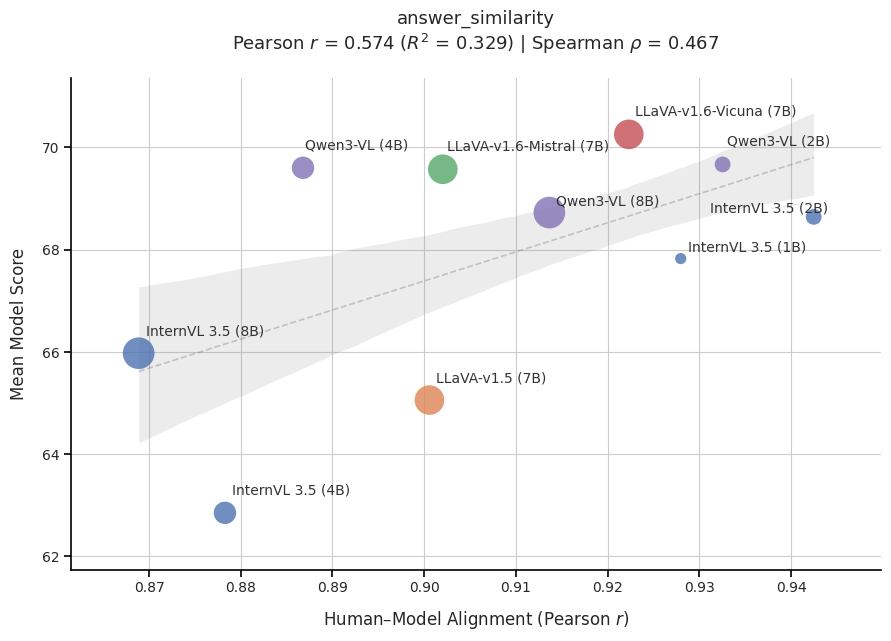

Pearson $r$ = -0.823 ($R^2$ = 0.677) | Spearman $\rho$ = -0.721


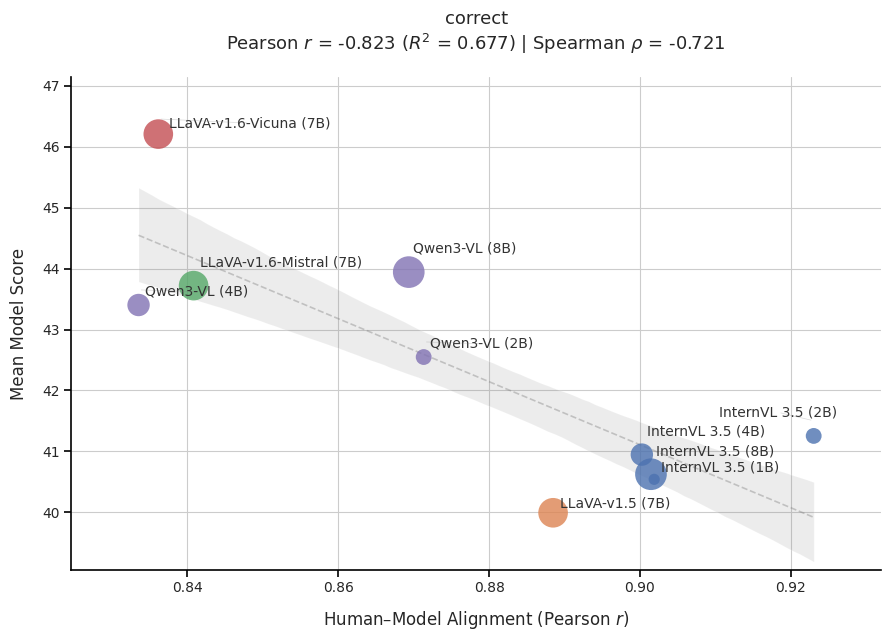

In [166]:
for score_col in grouped["eval_metric"].unique():
    subset = grouped[grouped["eval_metric"] == score_col].sort_values(by=['model_clean'])

    x = subset["pearson_r"].values
    y = subset["model_avg"].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, _ = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(9, 6.5))

    # 1. Regression line + CI (68% for cleaner look)
    sns.regplot(
        data=subset, x="pearson_r", y="model_avg",
        scatter=False, ci=68, ax=ax,
        line_kws=dict(color="gray", linestyle="--", linewidth=1.2, alpha=0.4),
    )

    # 2. Scatter points
    for fam in subset["family"].unique():
        fam_data = subset[subset["family"] == fam]
        ax.scatter(
            fam_data["pearson_r"], fam_data["model_avg"],
            s=fam_data["model_size"] * 65,
            alpha=0.8, label=fam, edgecolors="none", zorder=3
        )

    # 3. Labeling
    texts = []
    for _, row in subset.iterrows():
        text = ax.text(
            row["pearson_r"], row["model_avg"] + ((y.max() - y.min()) * 0.04),
            row["model_clean"],
            fontsize=10, color="#333333"
        )
        texts.append(text)

    adjust_text(
        texts,
        only_move={'points': 'y', 'text': 'xy'},
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3, lw=0.5),
        expand_text=(1.5, 2.8),
        expand_points=(1.5, 2.8),
        force_text=0.15,
        force_points=0.15,
        lim=300,
    )

    # 4. DISTINCT AXIS FORMATTING
    # Show the left and bottom spines (the "L" frame)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.2)
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Make ticks visible and pointing outward
    ax.tick_params(left=True, bottom=True, direction='out', color='black', width=1.2)

    # Tighten limits based on data
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.15
    ax.set_xlim(x.min() - x_margin, x.max() + x_margin)
    ax.set_ylim(y.min() - y_margin, y.max() + y_margin)
    
    ax.set_xlabel("Human–Model Alignment (Pearson $r$)", labelpad=10)
    ax.set_ylabel("Mean Model Score", labelpad=10)
    
    ax.set_title(
        f"{score_col}\n"
        f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}",
        pad=20,
    )

    print(f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}") 
    plt.tight_layout()
    plt.savefig(f"./figures/alignment_{score_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def draw_histograms_vqa(x, y, x2, y2, save=None): 
    fig, axes = plt.subplots(2, 1, figsize=(9, 8))

    # --- Accuracy plot ---
    sns.ecdfplot(x, label="Human", ax=axes[0])
    sns.ecdfplot(y, label="Model", ax=axes[0])
    axes[0].axvline(x.mean(), color='blue', ls='--', lw=1,
                    label=f'Human μ={x.mean():.3f}')
    axes[0].axvline(y.mean(), color='orange', ls='--', lw=1,
                    label=f'Model μ={y.mean():.3f}')
    axes[0].set_xlabel("Per-question accuracy")
    axes[0].set_ylabel("ECDF")
    axes[0].set_title("Accuracy")
    axes[0].legend(frameon=False)

    # --- Embedding plot ---
    sns.ecdfplot(x2, label="Human", ax=axes[1])
    sns.ecdfplot(y2, label="Model", ax=axes[1])
    axes[1].axvline(x2.mean(), color='blue', ls='--', lw=1,
                    label=f'Human μ={x2.mean():.3f}')
    axes[1].axvline(y2.mean(), color='orange', ls='--', lw=1,
                    label=f'Model μ={y2.mean():.3f}')
    axes[1].set_xlabel("Embedding similarity (cosine)")
    axes[1].set_ylabel("ECDF")
    axes[1].set_title("Embedding")
    axes[1].legend(frameon=False)

    sns.despine()
    plt.tight_layout()

    if save is None:
        plt.show()
    else:
        plt.savefig(f"./figures/align/{save}.png", bbox_inches='tight')
    plt.close()


In [33]:
len((pm['correct_human'])), len(pm['correct_model']), len(pm['answer_similarity_human']), len(pm['answer_similarity_model'] )

(4114, 4114, 4114, 4114)

In [34]:
len(qids)

374

In [45]:
cols = ['correct_model', 'answer_similarity_model', 'correct_human', 'answer_similarity_human']
for col in cols:
    pm[col] = pd.to_numeric(pm[col], errors='coerce')

pm = pm.groupby(['question_id'])[cols].mean()

/tmp/ipykernel_1961015/923178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm[col] = pd.to_numeric(pm[col], errors='coerce')


In [ ]:
draw_histograms_vqa(pm['correct_human'], pm['correct_model'], pm['answer_similarity_human'], pm['answer_similarity_model'], None) 


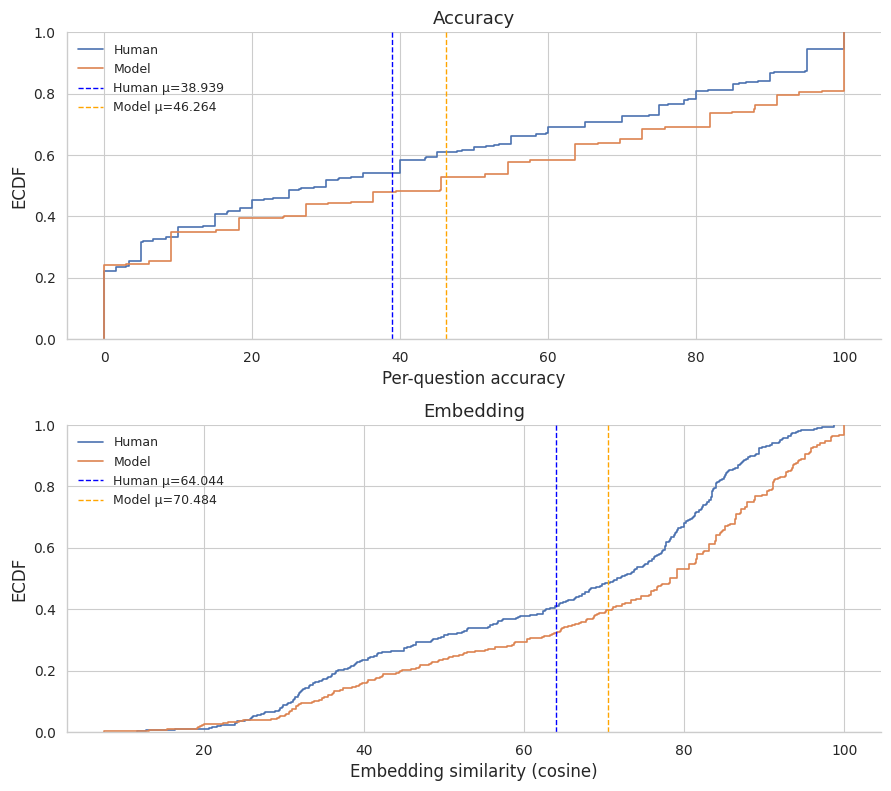

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
alignments = [] 

alignments.append(acc_stat)
alignments.append(emb_stat)
pd.DataFrame(alignments)

In [ ]:
from utils.align import calculate_alignment_suite 

def aligned_histogram(human_acc, model_acc, human_emb, model_emb, modelname='Pretrained VLMs'):  

    x,y,x2,y2= human_acc, model_acc, human_emb, model_emb 
    
    acc_stat = calculate_alignment_suite(x, y) 
    acc_stat['metric'] = 'accuracy' 
    acc_stat['model'] = modelname 

    emb_stat = calculate_alignment_suite(x2, y2) 
    emb_stat['metric'] = 'answer_similarity'
    emb_stat['model'] = modelname 
    
    draw_histograms_vqa(x, y, x2, y2, acc_stat['Pearson_r'], acc_stat['KS_Stat'], emb_stat['Pearson_r'], emb_stat['KS_Stat'], modelname) 

    print(f"Accuracy\n$r={acc_stat['Pearson_r']:.2f}$, KS={acc_stat['KS_Stat']:.2f}")
    print(f"Embedding\n$r={emb_stat['Pearson_r']:.2f}$, KS={emb_stat['KS_Stat']:.2f}") 
    return acc_stat, emb_stat


Accuracy
$r=0.46$, KS=0.50
Embedding
$r=0.58$, KS=0.47


,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.460,"[0.446, 0.474]",0.467,0.397,0.564,0.629,0.499,21.628,19.806,accuracy,Pretrained VLMs
1,0.582,"[0.57, 0.594]",0.492,0.489,0.609,0.637,0.471,12.942,12.538,answer_similarity,Pretrained VLMs


In [150]:
for model in mg.model.unique():  
    df = mg[mg['model'] == model] 
    acc_stat, emb_stat = aligned_histogram(df['correct_human'], df['correct_model'], df['answer_similarity_human'], df['answer_similarity_model'], model) 

    alignments.append(acc_stat)
    alignments.append(emb_stat)
    
pd.DataFrame(alignments)

Accuracy
$r=0.65$, KS=0.35
Embedding
$r=0.74$, KS=0.32
Accuracy
$r=0.63$, KS=0.37
Embedding
$r=0.76$, KS=0.35
Accuracy
$r=0.71$, KS=0.39
Embedding
$r=0.67$, KS=0.19
Accuracy
$r=0.73$, KS=0.37
Embedding
$r=0.70$, KS=0.29
Accuracy
$r=0.55$, KS=0.37
Embedding
$r=0.72$, KS=0.34
Accuracy
$r=0.64$, KS=0.39
Embedding
$r=0.67$, KS=0.36
Accuracy
$r=0.65$, KS=0.39
Embedding
$r=0.71$, KS=0.35
Accuracy
$r=0.50$, KS=0.38
Embedding
$r=0.66$, KS=0.37
Accuracy
$r=0.56$, KS=0.43
Embedding
$r=0.68$, KS=0.40
Accuracy
$r=0.73$, KS=0.42
Embedding
$r=0.74$, KS=0.39
Accuracy
$r=0.75$, KS=0.41
Embedding
$r=0.74$, KS=0.38
Accuracy
$r=0.73$, KS=0.39
Embedding
$r=0.73$, KS=0.31
Accuracy
$r=0.76$, KS=0.40
Embedding
$r=0.73$, KS=0.38
Accuracy
$r=0.52$, KS=0.45
Embedding
$r=0.65$, KS=0.42
Accuracy
$r=0.53$, KS=0.41
Embedding
$r=0.66$, KS=0.39
Accuracy
$r=0.76$, KS=0.38
Embedding
$r=0.73$, KS=0.34
Accuracy
$r=0.76$, KS=0.39
Embedding
$r=0.73$, KS=0.35
Accuracy
$r=0.66$, KS=0.39
Embedding
$r=0.73$, KS=0.36
Accuracy
$

,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.597,"[0.577, 0.616]",0.602,0.561,0.564,0.612,0.378,14.404,7.326,accuracy,None
1,0.694,"[0.678, 0.71]",0.634,0.638,0.548,0.576,0.337,7.888,6.440,answer_similarity,None
2,0.650,"[0.587, 0.705]",0.651,0.613,0.564,0.609,0.353,13.553,4.911,accuracy,InternVL3_5-1B
3,0.736,"[0.685, 0.779]",0.681,0.680,0.572,0.606,0.321,7.806,5.847,answer_similarity,InternVL3_5-1B
4,0.629,"[0.563, 0.686]",0.651,0.590,0.567,0.614,0.374,14.693,6.337,accuracy,InternVL3_5-2B
...,...,...,...,...,...,...,...,...,...,...,...
67,0.578,"[0.506, 0.642]",0.472,0.477,0.602,0.633,0.455,13.535,13.471,answer_similarity,llava-v1.6-mistral-7b-hf_SFT_vqa_gt
68,0.501,"[0.42, 0.573]",0.513,0.476,0.564,0.609,0.348,13.508,4.733,accuracy,llava-1.5-7b-hf
69,0.686,"[0.628, 0.736]",0.621,0.629,0.610,0.652,0.350,7.518,4.570,answer_similarity,llava-1.5-7b-hf
70,0.499,"[0.418, 0.571]",0.510,0.461,0.564,0.616,0.401,15.666,10.170,accuracy,llava-v1.6-vicuna-7b-hf


In [55]:
results_df = pd.DataFrame(alignments)
rename_map = {
    "Spearman_rho": "Spearman_ρ (↑)",
    "Kappa_Quad": "Kappa_Quad (↑)",
    "TVD": "TVD (↓)",
    "JS_Dist": "JS_Dist (↓)",
    "KS_Stat": "KS_Stat (↓)",
    "Wasserstein": "Wasserstein (↓)",
    "Delta_Mean": "Δ_Mean (→0)",  # Bias is best when close to zero
    "metric": "Metric"
}

results_df = results_df.rename(columns=rename_map)
# Debug: Some columns may not be numeric, causing aggfunc='mean' to fail. Select only numeric columns.
numeric_cols = results_df.select_dtypes(include='number').columns
# Keep 'model' and 'Metric' for pivot
pivot_cols = ['model', 'Metric'] + list(numeric_cols.difference(['model', 'Metric']))
pivot_df = results_df[pivot_cols]
pivot_df = pivot_df.pivot_table(index='model', columns='Metric', aggfunc='mean')
pivot_df.to_csv('./tables/alignment.csv')
pivot_df

JS_Dist (↓)  \
Metric                                               accuracy   
model                                                           
InternVL3_5-1B                                          0.624   
InternVL3_5-2B                                          0.628   
InternVL3_5-4B                                          0.629   
InternVL3_5-8B                                          0.632   
InternVL3_5-8B_A1_vqa_gt                                0.655   
InternVL3_5-8B_A2_vqa_10_blind_inst                     0.652   
InternVL3_5-8B_A3_vqa_15_blind_inst                     0.650   
InternVL3_5-8B_A4_mmstar_15_blind_inst                  0.647   
InternVL3_5-8B_SFT_vqa_15_blind_inst                    0.650   
InternVL3_5-8B_SFT_vqa_gt                               0.659   
Pretrained VLMs                                         0.629   
Qwen3-4B                                                0.640   
Qwen3-VL-2B-Instruct                                    0.628   
Qwen3-VL-4B-Instruct                                    0.631   
Qwen3-VL-4B-Instruct_A1_vqa_gt                          0.653   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst               0.645   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst               0.647   
Qwen3-VL-4B-Instruct_A4_mmstar_15_blind_inst            0.646   
Qwen3-VL-4B-Instruct_SFT_vqa_15_blind_inst              0.645   
Qwen3-VL-4B-Instruct_SFT_vqa_gt                         0.657   
Qwen3-VL-8B-Instruct                                    0.633   
Qwen3-VL-8B-Instruct_A1_vqa_gt                          0.650   
Qwen3-VL-8B-Instruct_A2_vqa_10_blind_inst               0.647   
Qwen3-VL-8B-Instruct_A3_vqa_15_blind_inst               0.650   
Qwen3-VL-8B-Instruct_A4_mmstar_15_blind_inst            0.650   
Qwen3-VL-8B-Instruct_SFT_mmstar_15_blind_inst           0.650   
Qwen3-VL-8B-Instruct_SFT_vqa_15_blind_inst              0.648   
llava-1.5-7b-hf                                         0.626   
llava-v1.6-mistral-7b-hf                                0.631   
llava-v1.6-mistral-7b-hf_A1_vqa_gt                      0.662   
llava-v1.6-mistral-7b-hf_A2_vqa_10_blind_inst           0.644   
llava-v1.6-mistral-7b-hf_A3_vqa_15_blind_inst           0.646   
llava-v1.6-mistral-7b-hf_A4_mmstar_15_blind_inst        0.653   
llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst       0.656   
llava-v1.6-mistral-7b-hf_SFT_vqa_15_blind_inst          0.638   
llava-v1.6-mistral-7b-hf_SFT_vqa_gt                     0.660   
llava-v1.6-vicuna-7b-hf                                 0.634   

                                                                     \
Metric                                            answer_similarity   
model                                                                 
InternVL3_5-1B                                                0.634   
InternVL3_5-2B                                                0.628   
InternVL3_5-4B                                                0.554   
InternVL3_5-8B                                                0.609   
InternVL3_5-8B_A1_vqa_gt                                      0.678   
InternVL3_5-8B_A2_vqa_10_blind_inst                           0.669   
InternVL3_5-8B_A3_vqa_15_blind_inst                           0.663   
InternVL3_5-8B_A4_mmstar_15_blind_inst                        0.633   
InternVL3_5-8B_SFT_vqa_15_blind_inst                          0.661   
InternVL3_5-8B_SFT_vqa_gt                                     0.685   
Pretrained VLMs                                               0.637   
Qwen3-4B                                                      0.817   
Qwen3-VL-2B-Instruct                                          0.639   
Qwen3-VL-4B-Instruct                                          0.663   
Qwen3-VL-4B-Instruct_A1_vqa_gt                                0.693   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst                     0.652   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst                     0.651   
Qwen3-VL-4B-Instruct_A4_mmsta